Fine-tuning di un modello di linguaggio neurale (Neural Language
Model).
 Lo studente dovrà selezionare un neural language model tra quelli
trattati durante il corso e condurre un processo di fine-tuning per un
totale di 6 epoche. Per questa fase, è richiesto di:
  presentare le curve di loss relative al training e al validation set;
  riportare le prestazioni del modello sul validation set al termine di
ciascuna epoca;
  valutare il modello sul test set al termine della sesta epoca.

In [1]:
!pip install --upgrade datasets
!pip install evaluate
!pip install transformers
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00


In [2]:
import os
from google.colab import drive

import numpy as np
import pandas as pd

import datasets
import evaluate
import seaborn as sns

# Libreria transformers per utilizzare i Transformer models
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Librerie per le metriche
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

Caricamento di dati

In [3]:
training_path = "/content/drive/MyDrive/LC2 progetto/dataset/training/"
test_path = "/content/drive/MyDrive/LC2 progetto/dataset/test/"
val_path = "/content/drive/MyDrive/LC2 progetto/dataset/validation/"

# funzione di estrazione delle informazioni dei file
def estrai_doc(path, lista_doc):
    documents = os.listdir(path)

    for document in documents:

        # mi assicuro di prendere solo i file txt
        if document.endswith(".txt"):

            data = open(path + document, 'r')
            text = data.read()
            # creo un dizionario che conterrà sentence, label e id del documento
            input_instance = {}
            id_doc = (document.split('.')[0]).split("/")[-1]
            labels_doc = id_doc.split('_')[0]
            input_instance["id_doc"] = id_doc
            input_instance["label"] = labels_doc
            input_instance["sentence"] = text

            # appendo le informazioni estratte nel dizionario
            lista_doc.append(input_instance)

    return lista_doc

    # numero labels = 3 (le tre autrici)
labels = ["austen", "dickens", "woolf"]

# Creo un dizionario di mapping fra le labels come stringhe e le label numeriche
str_to_int = {label: num for num, label in enumerate(labels)}

In [4]:
train_data = []
test_data = []
val_data = []

train_data= estrai_doc(training_path, train_data)
test_data = estrai_doc(test_path, test_data)
val_data = estrai_doc(val_path, val_data)

In [5]:
train_data[0]
# print(len(train_data))
# print(len(test_data))
# print(len(val_data))

{'id_doc': 'woolf_1_training',
 'label': 'woolf',
 'sentence': 'As the streets that lead from the Strand to the Embankment are very narrow, it is better not to walk down them arm-in-arm. If you persist, lawyers’ clerks will have to make flying leaps into the mud; young lady typists will have to fidget behind you. In the streets of London where beauty goes unregarded, eccentricity must pay the penalty, and it is better not to be very tall, to wear a long blue cloak, or to beat the air with your left hand.'}

In [6]:
# Conversione da lista di dizionari a dataset
train = datasets.Dataset.from_pandas(pd.DataFrame(data=train_data))
test = datasets.Dataset.from_pandas(pd.DataFrame(data=test_data))
val = datasets.Dataset.from_pandas(pd.DataFrame(data=val_data))

# Stampo 'train' per vedere come è formattato
print(train)
print()
print("Esempio di testo:", train['sentence'][2])
print()
print("Esempio di label:", train['label'][2])
print()
print("Esempio di id:", train['id_doc'][2])
print()

# Shape dei dati di train, dev e test
print("Dimensione dei training, development and test sets:")
print("Train:", train.shape)
print("Dev:", val.shape)
print("Test:", test.shape)

Dataset({
    features: ['id_doc', 'label', 'sentence'],
    num_rows: 3000
})

Esempio di testo: Observing that they passed no other hansom cab, but only vans and waggons, and that not one of the thousand men and women she saw was either a gentleman or a lady, Mrs. Ambrose understood that after all it is the ordinary thing to be poor, and that London is the city of innumerable poor people. Startled by this discovery and seeing herself pacing a circle all the days of her life round Picadilly Circus she was greatly relieved to pass a building put up by the London County Council for Night Schools.

Esempio di label: woolf

Esempio di id: woolf_3_training

Dimensione dei training, development and test sets:
Train: (3000, 3)
Dev: (300, 3)
Test: (300, 3)


Carica modello

In [8]:

# Seleziono il modello
model_name = 'bert-base-uncased'

# Carico il modello per la classificazione
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels))


# Carico il tokenizzatore
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

preprocessing dei dati

In [9]:
tokenizer(train[0]["sentence"], padding=True, truncation=True, max_length=512)

{'input_ids': [101, 2004, 1996, 4534, 2008, 2599, 2013, 1996, 11226, 2000, 1996, 22756, 2024, 2200, 4867, 1010, 2009, 2003, 2488, 2025, 2000, 3328, 2091, 2068, 2849, 1011, 1999, 1011, 2849, 1012, 2065, 2017, 29486, 1010, 9559, 1521, 26706, 2097, 2031, 2000, 2191, 3909, 29195, 2046, 1996, 8494, 1025, 2402, 3203, 5939, 18136, 3215, 2097, 2031, 2000, 10882, 24291, 2369, 2017, 1012, 1999, 1996, 4534, 1997, 2414, 2073, 5053, 3632, 4895, 2890, 13444, 2098, 1010, 18080, 3012, 2442, 3477, 1996, 6531, 1010, 1998, 2009, 2003, 2488, 2025, 2000, 2022, 2200, 4206, 1010, 2000, 4929, 1037, 2146, 2630, 11965, 1010, 2030, 2000, 3786, 1996, 2250, 2007, 2115, 2187, 2192, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [10]:
# tokenizzazione
# Funzione che applica la tokenizzazione ai dati di training, dev e test
def tokenize(batch):
    tokens = tokenizer(batch['sentence'], padding=True, truncation=True, max_length=512)
    tokens['label'] = [str_to_int[label] for label in batch["label"]]

    return tokens

train = train.map(tokenize, batched=True)
val = val.map(tokenize, batched=True)
test = test.map(tokenize, batched=True)

train.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])
val.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])
test.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Addestramento

In [11]:
# Trainer

num_epochs = 6

training_args = TrainingArguments(
    f"{model_name}-finetuned",
    eval_strategy = "epoch",
    logging_strategy="epoch",
    save_strategy = "epoch",
    logging_steps=10,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

In [12]:
# metrica
def compute_metrics(eval_pred):
  f1_metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)

  return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [13]:

trainer = Trainer(
    model,
    training_args,
    train_dataset=train,
    eval_dataset=val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.save_model("/content/drive/MyDrive/LC2 progetto/bert")

/tmp/ipython-input-655091630.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: martinaperodi5 (martinaperodi5-universit-di-pisa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1
1,0.301800,0.734265,0.795049
2,0.031200,1.316533,0.752651
3,0.003800,1.107043,0.799610
4,0.000400,1.175619,0.802832
5,0.000200,1.189114,0.802832
6,0.000200,1.196141,0.805903


evaluation del modello

/tmp/ipython-input-3189889830.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, log_df], ignore_index=True)


<Axes: xlabel='Epoch', ylabel='Loss'>

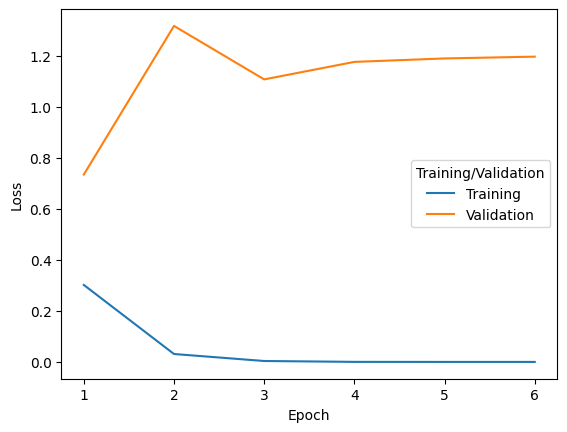

In [14]:
# monitoraggio loss
log_history = trainer.state.log_history

# Creo dataframe pandas per memorizzare le loss di training/evaluation e poi mostrare graficamente le curve
df = pd.DataFrame(columns=["Epoch", "Loss", "Training/Validation"])

for log_data in log_history:
  epoch = int(log_data["epoch"])
  if "loss" in log_data.keys():
    loss = log_data["loss"]

    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Training"]})
    df = pd.concat([df, log_df], ignore_index=True)
  if "eval_loss" in log_data.keys():
    loss = log_data["eval_loss"]
    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Validation"]})
    df = pd.concat([df, log_df], ignore_index=True)

# Lineplot della loss
sns.lineplot(data=df, x="Epoch", y="Loss", hue="Training/Validation")

In [15]:
# calcolo sul test set

output_predictions = trainer.predict(test)
print(output_predictions)

PredictionOutput(predictions=array([[-1.5663733 , -0.54139286,  2.1564648 ],
       [-2.7642975 ,  3.608646  , -0.99359566],
       [-0.89631826,  2.7041721 , -1.6452974 ],
       [-2.5499668 ,  2.686207  , -0.517463  ],
       [-2.4044807 , -1.3558993 ,  3.8287728 ],
       [-2.4408822 , -0.08983909,  2.4590209 ],
       [ 0.0645574 ,  1.1770959 , -1.1963385 ],
       [-0.8928584 , -1.7526882 ,  3.0027854 ],
       [-0.6715754 , -2.7844055 ,  4.005257  ],
       [ 0.03919506, -0.9202209 ,  1.259036  ],
       [-1.9729753 ,  1.7391127 , -0.00473325],
       [-2.0614576 ,  2.062971  , -0.06589904],
       [-2.9440804 ,  3.8720596 , -1.340431  ],
       [-1.7628776 ,  3.5945857 , -2.1808636 ],
       [ 0.6297065 , -1.4225183 ,  1.2628869 ],
       [-2.922729  ,  2.8547945 , -0.29482138],
       [-0.28634048, -2.901294  ,  3.9854004 ],
       [-1.8224641 ,  3.2998083 , -1.7339627 ],
       [-0.17787364, -2.73788   ,  3.7904239 ],
       [-3.6187027 ,  1.9942117 ,  1.2985024 ],
       [-2.

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       100
           1       0.77      0.63      0.69       100
           2       0.59      0.77      0.67       100

    accuracy                           0.74       300
   macro avg       0.77      0.74      0.75       300
weighted avg       0.77      0.74      0.75       300


Confusion Matrix:


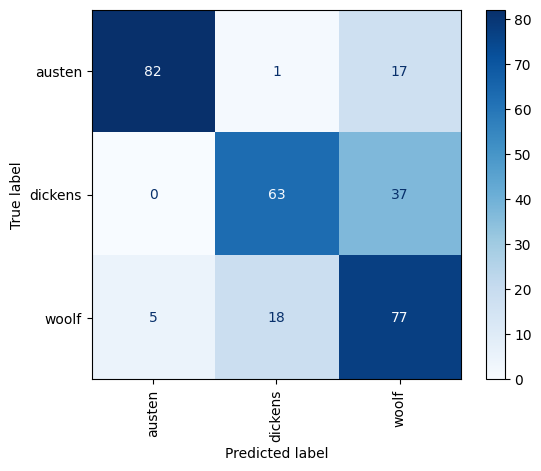

In [16]:
y_test = test["label"] # Access the column as a list-like object
y_pred = np.argmax(output_predictions.predictions, axis=1)

report = classification_report(y_test, y_pred)
# cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation='vertical', cmap='Blues')

# print("Classification Report:")
# print(report)
# print()

# print("Confusion Matrix:")
# print(cm)

# Recupera la lista delle etichette nell'ordine corretto
labels = ["austen", "dickens", "woolf"]
str_to_int = {label: num for num, label in enumerate(labels)}
int_to_str = {v: k for k, v in str_to_int.items()}

# Ottengo i nomi delle etichette ordinati per indice numerico
display_labels = [int_to_str[i] for i in range(len(labels))]

# Stampo la matrice di confusione con i nomi delle etichette
cm = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=display_labels,
    xticks_rotation='vertical',
    cmap='Blues'
)

print("Classification Report:")
print(report)
print()
print("Confusion Matrix:")
print(cm)